In [60]:
from lib.readwav import readwav
from lib.functions import get_f0_from_peaks, extract_harmonics, get_average_spectrum, get_adaptive_params, find_closest_note, get_f0_from_regression
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [61]:
%matplotlib widget
plt.close('all')

(332193, 2)
Frequenza fondamentale stimata: 1563.44 Hz


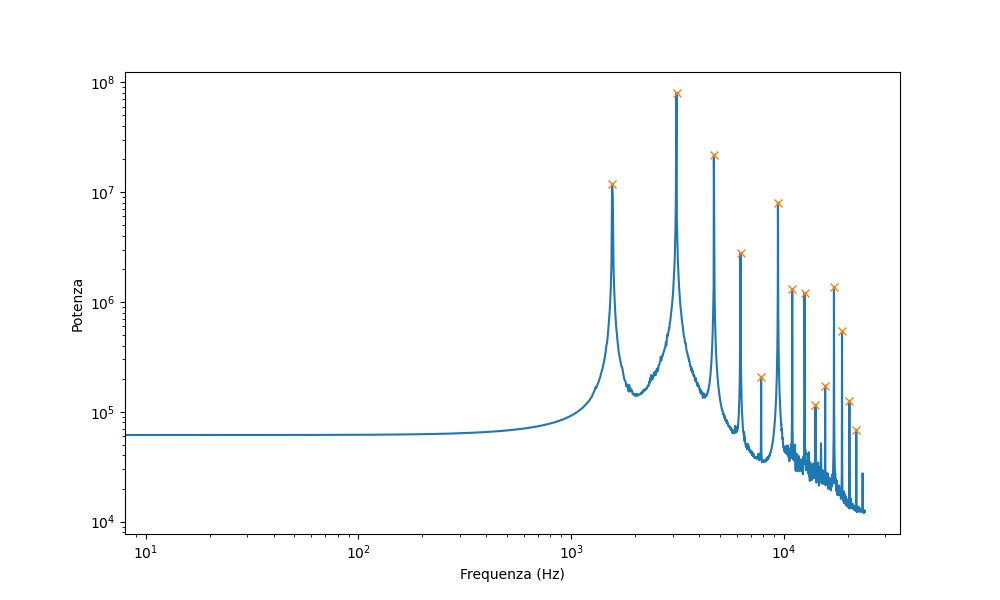

In [62]:
note_data = readwav('Data_organ/note_1.wav')
rate, data = note_data
print(data.shape)
channel1 = data[:,0]
channel2 = data[:,1]

window_size, hop_size = get_adaptive_params(channel1, rate)
freqs, power_spectrum = get_average_spectrum(channel1, rate, window_size, hop_size)

peaks, _ = sp.signal.find_peaks(power_spectrum, prominence=5*1e4)

f0 = get_f0_from_regression(freqs[peaks])
print(f"Frequenza fondamentale stimata: {f0:.2f} Hz")


plt.figure(figsize=(10, 6))
plt.plot(freqs, power_spectrum)
plt.plot(freqs[peaks], power_spectrum[peaks], 'x')
plt.xscale('log')
plt.xlabel('Frequenza (Hz)')
plt.ylabel('Potenza')
plt.yscale('log')
plt.show()

File indices: [1, 31, 61, 91, 121, 151, 181]


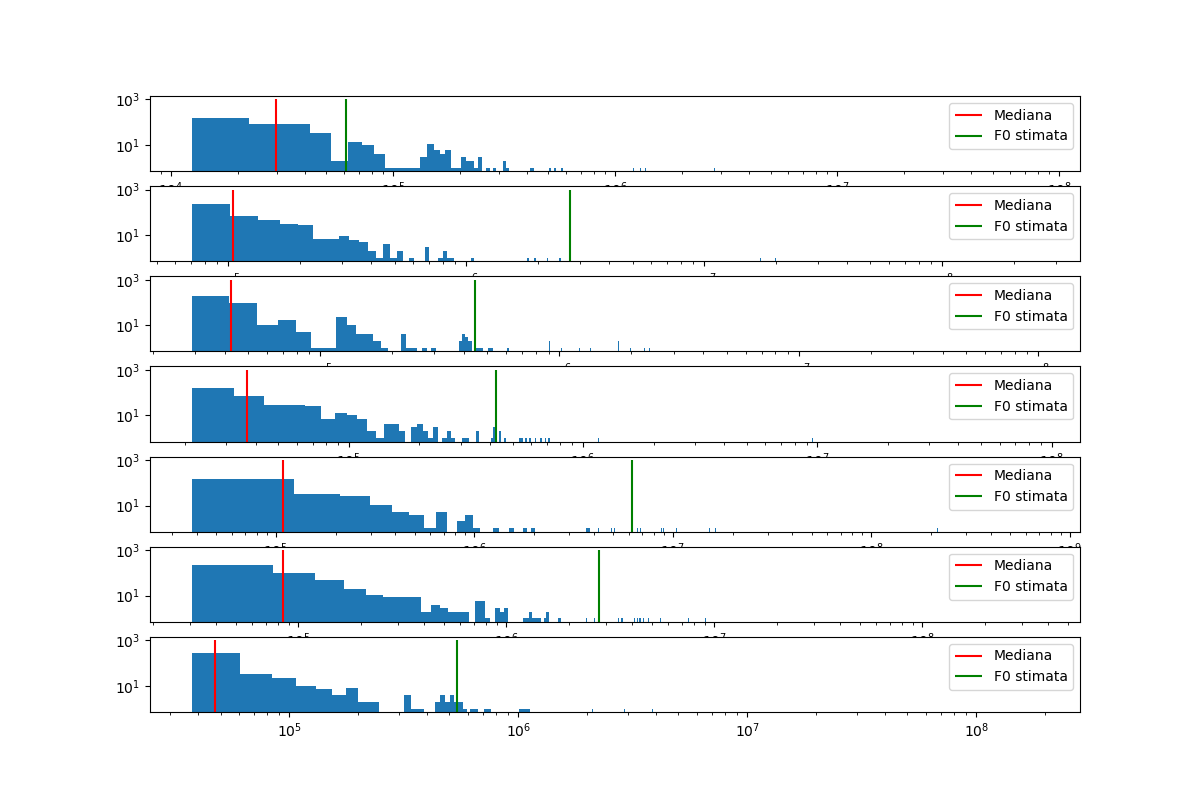

In [ ]:
"""peaks_hist, _ = sp.signal.find_peaks(power_spectrum, prominence=1e3)


plt.figure(figsize=(10, 6))
rate, data = note_data
print(data.shape)
channel1 = data[:,0]
channel2 = data[:,1]
"""

file_indices = list(range(1, 200, 30))
print(f"File indices: {file_indices}")  

num_plots = len(file_indices)

plt.figure(figsize=(12, 8))
plt.subplot(num_plots, 1, 1)

for i in file_indices:
    note_data = readwav(f'Data_organ/note_{i}.wav')
    rate, data = note_data
    channel1 = data[:,0]

    window_size, hop_size = get_adaptive_params(channel1, rate)
    freqs, power_spectrum = get_average_spectrum(channel1, rate, window_size, hop_size)
    
    #power_spectrum_2 = np.abs(power_spectrum)**2
    adaptive_prominence = 1e-5 * np.max(power_spectrum)

    peaks_hist, _ = sp.signal.find_peaks(power_spectrum, prominence=1e2)

    peaks_hist_f0, _ = sp.signal.find_peaks(power_spectrum, prominence=adaptive_prominence)

    median_power = np.median(power_spectrum[peaks_hist])

    f0 = round(get_f0_from_regression(freqs[peaks_hist_f0]))
    f0_index = np.argmin(np.abs(freqs - f0))

    plt.subplot(num_plots, 1, i//30 + 1)

    plt.hist(power_spectrum[peaks_hist], bins=8000)

    plt.vlines(median_power, 0, 1000, colors='r', label='Mediana')
    plt.vlines(power_spectrum[f0_index], 0, 1000, colors='g', label='F0 stimata')
    plt.legend()

    plt.yscale('log')

    plt.xscale('log')

    binned_power = np.


plt.show()



(336214, 2)
Frequenza fondamentale stimata: 106.72 Hz


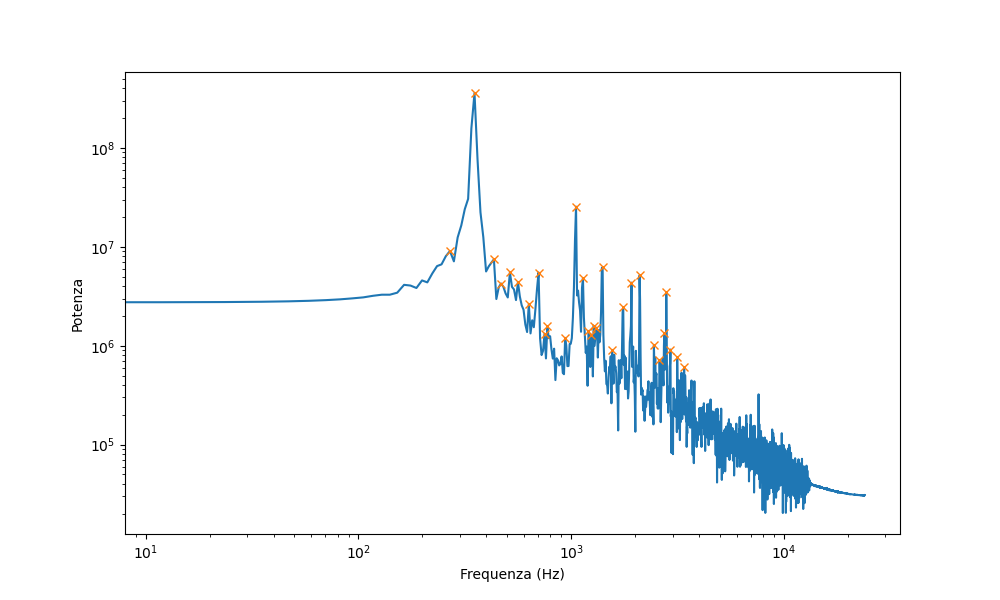

In [64]:
note_data = readwav('Data_organ/note_151.wav')
rate, data = note_data
print(data.shape)
channel1 = data[:,0]
channel2 = data[:,1]

window_size, hop_size = get_adaptive_params(channel1, rate)
freqs, power_spectrum = get_average_spectrum(channel1, rate, window_size, hop_size)

power_spectrum_mean = np.mean(power_spectrum)

peaks, _ = sp.signal.find_peaks(power_spectrum-power_spectrum_mean, prominence=470_000)

f0 = get_f0_from_regression(freqs[peaks])
print(f"Frequenza fondamentale stimata: {f0:.2f} Hz")


plt.figure(figsize=(10, 6))
plt.plot(freqs, power_spectrum)
plt.plot(freqs[peaks], power_spectrum[peaks], 'x')
plt.xscale('log')
plt.xlabel('Frequenza (Hz)')
plt.ylabel('Potenza')
plt.yscale('log')
plt.show()

F0 stimata: 55.82 Hz


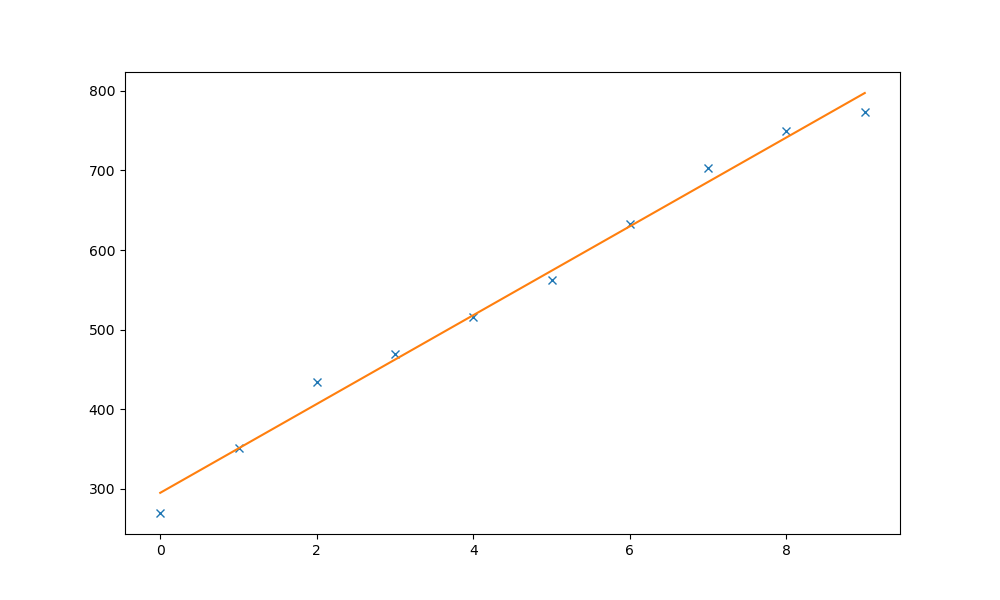

In [65]:
first_10_peaks = peaks[:10]

plt.figure(figsize=(10, 6))
plt.plot(freqs[first_10_peaks], 'x')

#fit lineare
x = np.arange(len(first_10_peaks))
#y = np.zeros(len(first_10_peaks)+1)
#y[0] = 0
y = freqs[first_10_peaks]

coefficients = np.polyfit(x, y, 1)

plt.plot(x, np.polyval(coefficients, x), label='Fit Lineare')


f0 = coefficients[0]
print(f"F0 stimata: {f0:.2f} Hz")